<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/pronosticos_LTSM_tesis_jaime_mario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install keras

In [1]:
!pip install tensorflow
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Cargar el conjunto de datos
file_path = 'dataset_completo_google_amazon.csv'
df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')

# Asegurarse de que el dataset esté ordenado por fecha
df = df.sort_index()

print("Dataset cargado exitosamente. Últimas 5 filas:")
print(df.tail())

Dataset cargado exitosamente. Últimas 5 filas:
            GOOGL_Close  AMZN_Close  Treasury_10Y        VIX        SP500  \
Date                                                                        
2024-12-23   194.406113  225.059998         4.599  16.780001  5974.069824   
2024-12-24   195.884399  229.050003         4.591  14.270000  6040.040039   
2024-12-26   195.375000  227.050003         4.579  14.730000  6037.589844   
2024-12-27   192.538254  223.750000         4.619  15.950000  5970.839844   
2024-12-30   191.020004  221.300003         4.545  17.400000  5906.939941   

                  NASDAQ  GOOGL_Return_1d  AMZN_Return_1d  \
Date                                                        
2024-12-23  19764.880859         0.016823        0.000622   
2024-12-24  20031.130859         0.007604        0.017729   
2024-12-26  20020.359375        -0.002601       -0.008732   
2024-12-27  19722.029297        -0.014519       -0.014534   
2024-12-30  19486.789062        -0.007885      

In [5]:
# Seleccionar solo las columnas de precios de cierre
df_bivariate = df[['GOOGL_Close', 'AMZN_Close']].copy()

# Normalizar los datos: es un paso crucial para las redes neuronales
scaler_bivariate = MinMaxScaler(feature_range=(0, 1))
scaled_data_bivariate = scaler_bivariate.fit_transform(df_bivariate)

# Función para crear secuencias de datos para el LSTM
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:(i + n_steps), :])
        y.append(data[i + n_steps, :]) # Predecir el siguiente paso para ambas series
    return np.array(X), np.array(y)

# Definir el número de pasos de tiempo (días) que el modelo mirará hacia atrás
n_steps = 60 # Usaremos 60 días de datos históricos para predecir el siguiente día

# Crear las secuencias
X_bivariate, y_bivariate = create_sequences(scaled_data_bivariate, n_steps)

print("Forma de las secuencias de entrada (X):", X_bivariate.shape)
print("Forma de las secuencias de salida (y):", y_bivariate.shape)

Forma de las secuencias de entrada (X): (937, 60, 2)
Forma de las secuencias de salida (y): (937, 2)


In [6]:
# División temporal para mantener la cronología
train_size_bivariate = int(len(X_bivariate) * 0.8)
X_train_biv, X_test_biv = X_bivariate[:train_size_bivariate], X_bivariate[train_size_bivariate:]
y_train_biv, y_test_biv = y_bivariate[:train_size_bivariate], y_bivariate[train_size_bivariate:]

print("Tamaño del conjunto de entrenamiento:", X_train_biv.shape)
print("Tamaño del conjunto de prueba:", X_test_biv.shape)

Tamaño del conjunto de entrenamiento: (749, 60, 2)
Tamaño del conjunto de prueba: (188, 60, 2)


In [7]:
# Definir la arquitectura del modelo
model_bivariate = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train_biv.shape[1], X_train_biv.shape[2])),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=2) # 2 neuronas de salida para predecir GOOGL y AMZN
])

# Compilar el modelo
model_bivariate.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
print("\nEntrenando el modelo LSTM bivariante...")
history_bivariate = model_bivariate.fit(X_train_biv, y_train_biv, epochs=50, batch_size=32, validation_split=0.1, verbose=1)
print("Entrenamiento completado.")


Entrenando el modelo LSTM bivariante...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 0.0694 - val_loss: 0.0221
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0091 - val_loss: 0.0076
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0059 - val_loss: 0.0086
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0059 - val_loss: 0.0027
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0043 - val_loss: 0.0036
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0047 - val_loss: 0.0023
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0045 - val_loss: 0.0041
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0045 - val_loss: 0.0021
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0044 - val_loss: 0.0028
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0042 - val_loss: 0.0029
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0036 - val_loss: 0.0020
Epoch 12/50
22/22 ━━

In [8]:
# Realizar predicciones en el conjunto de prueba
predictions_biv_scaled = model_bivariate.predict(X_test_biv)

# Invertir la normalización para obtener los precios reales
predictions_biv = scaler_bivariate.inverse_transform(predictions_biv_scaled)
y_test_biv_real = scaler_bivariate.inverse_transform(y_test_biv)

# Calcular métricas de error
mse_googl_biv = mean_squared_error(y_test_biv_real[:, 0], predictions_biv[:, 0])
mae_googl_biv = mean_absolute_error(y_test_biv_real[:, 0], predictions_biv[:, 0])

mse_amzn_biv = mean_squared_error(y_test_biv_real[:, 1], predictions_biv[:, 1])
mae_amzn_biv = mean_absolute_error(y_test_biv_real[:, 1], predictions_biv[:, 1])

print("\n--- Métricas de Rendimiento del Modelo Bivariante ---")
print(f"GOOGL - MSE: {mse_googl_biv:.2f}, MAE: {mae_googl_biv:.2f}")
print(f"AMZN - MSE: {mse_amzn_biv:.2f}, MAE: {mae_amzn_biv:.2f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step

--- Métricas de Rendimiento del Modelo Bivariante ---
GOOGL - MSE: 69.42, MAE: 7.38
AMZN - MSE: 98.35, MAE: 8.44


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    """Función para calcular MAPE, evitando la división por cero."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Evitar división por cero si y_true es 0
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# Realizar predicciones en el conjunto de prueba
predictions_biv_scaled = model_bivariate.predict(X_test_biv)

# Invertir la normalización para obtener los precios reales
predictions_biv = scaler_bivariate.inverse_transform(predictions_biv_scaled)
y_test_biv_real = scaler_bivariate.inverse_transform(y_test_biv)

# --- Métricas para GOOGL ---
y_true_googl = y_test_biv_real[:, 0]
y_pred_googl = predictions_biv[:, 0]

mse_googl_biv = mean_squared_error(y_true_googl, y_pred_googl)
rmse_googl_biv = np.sqrt(mse_googl_biv)
mae_googl_biv = mean_absolute_error(y_true_googl, y_pred_googl)
r2_googl_biv = r2_score(y_true_googl, y_pred_googl)
mape_googl_biv = mean_absolute_percentage_error(y_true_googl, y_pred_googl)

# --- Métricas para AMZN ---
y_true_amzn = y_test_biv_real[:, 1]
y_pred_amzn = predictions_biv[:, 1]

mse_amzn_biv = mean_squared_error(y_true_amzn, y_pred_amzn)
rmse_amzn_biv = np.sqrt(mse_amzn_biv)
mae_amzn_biv = mean_absolute_error(y_true_amzn, y_pred_amzn)
r2_amzn_biv = r2_score(y_true_amzn, y_pred_amzn)
mape_amzn_biv = mean_absolute_percentage_error(y_true_amzn, y_pred_amzn)


# --- Imprimir Resultados ---
print("\n--- Métricas de Rendimiento del Modelo Bivariante ---")
print("\nPara GOOGL:")
print(f"  MSE: {mse_googl_biv:.2f}")
print(f"  RMSE: {rmse_googl_biv:.2f}")
print(f"  MAE: {mae_googl_biv:.2f}")
print(f"  R²: {r2_googl_biv:.4f}")
print(f"  MAPE: {mape_googl_biv:.2f}%")

print("\nPara AMZN:")
print(f"  MSE: {mse_amzn_biv:.2f}")
print(f"  RMSE: {rmse_amzn_biv:.2f}")
print(f"  MAE: {mae_amzn_biv:.2f}")
print(f"  R²: {r2_amzn_biv:.4f}")
print(f"  MAPE: {mape_amzn_biv:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

--- Métricas de Rendimiento del Modelo Bivariante ---

Para GOOGL:
  MSE: 69.42
  RMSE: 8.33
  MAE: 7.38
  R²: 0.4237
  MAPE: 4.27%

Para AMZN:
  MSE: 98.35
  RMSE: 9.92
  MAE: 8.44
  R²: 0.5710
  MAPE: 4.37%


In [10]:
# Período de pronóstico
n_future_days = len(pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), end='2025-03-31'))

# Tomar la última secuencia de datos reales del dataset completo
last_sequence_biv = scaled_data_bivariate[-n_steps:]
future_predictions_biv = []

current_batch = last_sequence_biv.reshape(1, n_steps, 2)

for i in range(n_future_days):
    # Predecir el siguiente paso
    future_pred = model_bivariate.predict(current_batch)[0]
    future_predictions_biv.append(future_pred)
    # Actualizar el batch para la siguiente predicción
    current_batch = np.append(current_batch[:, 1:, :], [[future_pred]], axis=1)

# Invertir la escala de las predicciones futuras
future_predictions_biv = scaler_bivariate.inverse_transform(future_predictions_biv)

# Crear un índice de fechas para el pronóstico
forecast_dates_biv = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=n_future_days)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━

In [12]:
# Crear un DataFrame con los pronósticos futuros del modelo bivariante
forecast_df_biv = pd.DataFrame({
    'GOOGL_Pronostico_Biv': future_predictions_biv[:, 0],
    'AMZN_Pronostico_Biv': future_predictions_biv[:, 1]
}, index=forecast_dates_biv)

# Cambiar el nombre del índice para mayor claridad
forecast_df_biv.index.name = 'Fecha_Pronostico'

# Mostrar una muestra de la tabla de pronósticos (inicio y final)
print("--- Muestra de Pronósticos a Futuro (Modelo Bivariante) ---")
print("\nInicio del período de pronóstico:")
print(forecast_df_biv.head())
print("\nFinal del período de pronóstico:")
print(forecast_df_biv.tail())

# (Opcional) Guardar la tabla completa en un CSV
forecast_df_biv.to_csv('forecast_bivariate_marzo2025.csv')

--- Muestra de Pronósticos a Futuro (Modelo Bivariante) ---

Inicio del período de pronóstico:
                  GOOGL_Pronostico_Biv  AMZN_Pronostico_Biv
Fecha_Pronostico                                           
2024-12-31                  182.545895           211.257116
2025-01-01                  180.941265           208.001461
2025-01-02                  178.801190           203.938828
2025-01-03                  176.422252           199.535655
2025-01-04                  173.971591           195.059616

Final del período de pronóstico:
                  GOOGL_Pronostico_Biv  AMZN_Pronostico_Biv
Fecha_Pronostico                                           
2025-03-27                  116.513640           113.838966
2025-03-28                  116.309157           113.586006
2025-03-29                  116.108534           113.337320
2025-03-30                  115.911678           113.092822
2025-03-31                  115.718514           112.852422


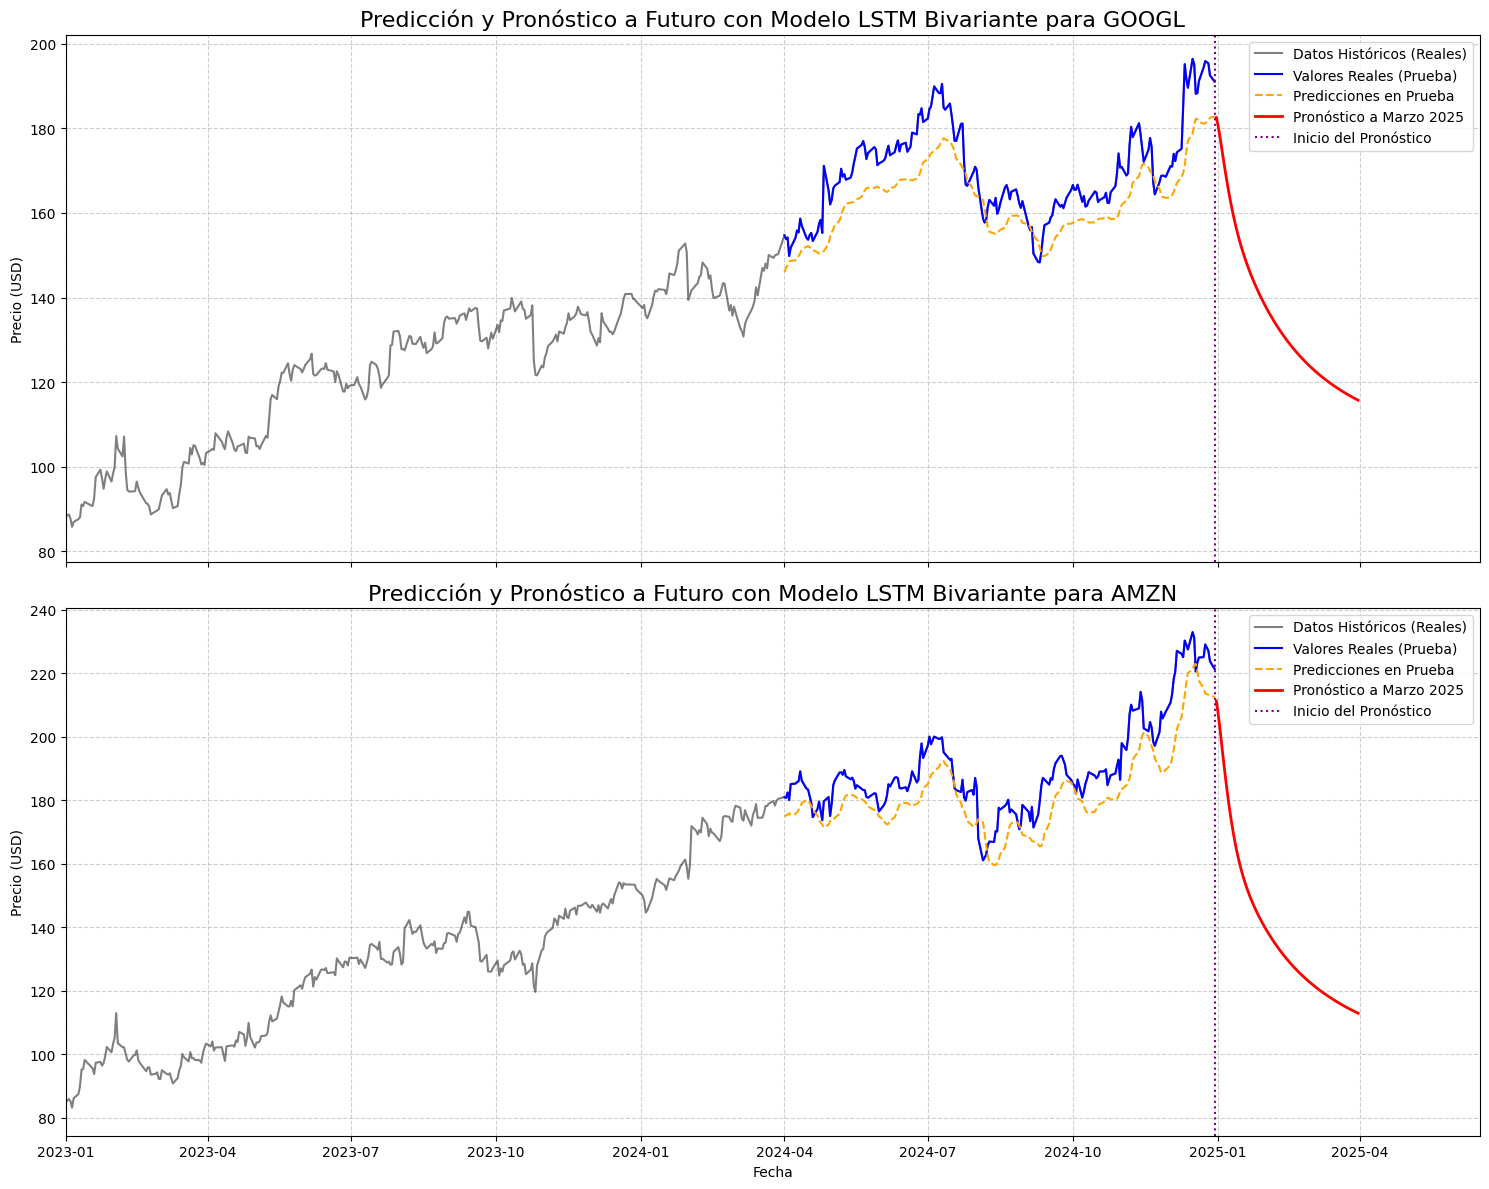

In [13]:
# Gráfico completo: Histórico + Predicciones en Prueba + Pronóstico a Futuro

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
test_dates = df_bivariate.index[train_size_bivariate+n_steps:]

# --- Gráfico para Google ---
ax1.plot(df.index, df['GOOGL_Close'], label='Datos Históricos (Reales)', color='black', alpha=0.5)
ax1.plot(test_dates, y_test_biv_real[:, 0], label='Valores Reales (Prueba)', color='blue')
ax1.plot(test_dates, predictions_biv[:, 0], label='Predicciones en Prueba', color='orange', linestyle='--')
ax1.plot(forecast_dates_biv, future_predictions_biv[:, 0], label='Pronóstico a Marzo 2025', color='red', linewidth=2)
ax1.axvline(df.index[-1], color='purple', linestyle=':', label='Inicio del Pronóstico')
ax1.set_title('Predicción y Pronóstico a Futuro con Modelo LSTM Bivariante para GOOGL', fontsize=16)
ax1.set_ylabel('Precio (USD)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_xlim(left=pd.to_datetime('2023-01-01')) # Hacemos zoom en el período más reciente

# --- Gráfico para Amazon ---
ax2.plot(df.index, df['AMZN_Close'], label='Datos Históricos (Reales)', color='black', alpha=0.5)
ax2.plot(test_dates, y_test_biv_real[:, 1], label='Valores Reales (Prueba)', color='blue')
ax2.plot(test_dates, predictions_biv[:, 1], label='Predicciones en Prueba', color='orange', linestyle='--')
ax2.plot(forecast_dates_biv, future_predictions_biv[:, 1], label='Pronóstico a Marzo 2025', color='red', linewidth=2)
ax2.axvline(df.index[-1], color='purple', linestyle=':', label='Inicio del Pronóstico')
ax2.set_title('Predicción y Pronóstico a Futuro con Modelo LSTM Bivariante para AMZN', fontsize=16)
ax2.set_ylabel('Precio (USD)')
ax2.set_xlabel('Fecha')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_xlim(left=pd.to_datetime('2023-01-01')) # Hacemos zoom en el período más reciente

plt.tight_layout()
plt.show()

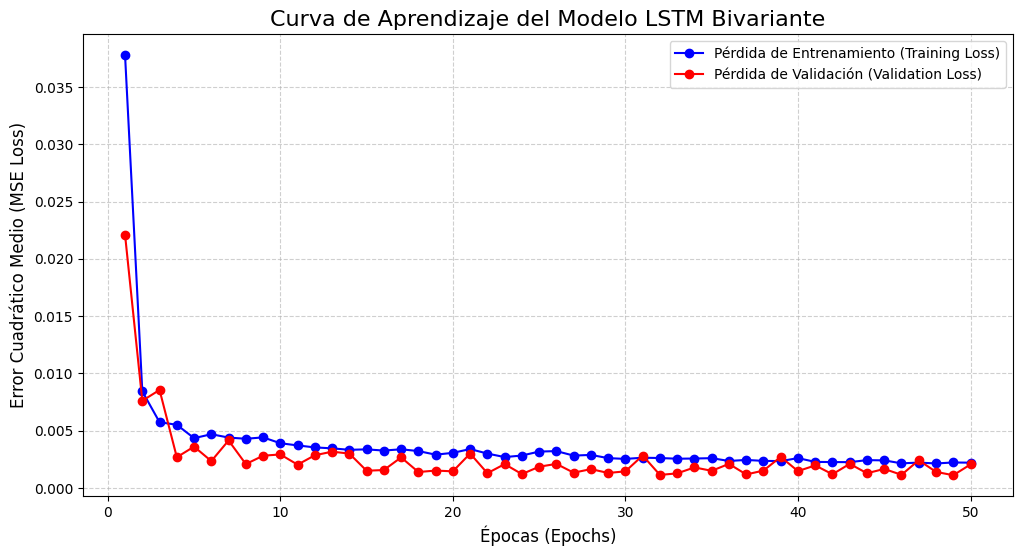


--- Análisis del Rendimiento del Entrenamiento (Modelo Bivariante) ---
Pérdida final en el conjunto de entrenamiento: 0.002212
Pérdida final en el conjunto de validación:  0.002057
--------------------------------------------------
Mínima pérdida de validación alcanzada: 0.001116 en la época 49

Advertencia: Se observa una posible señal de sobreajuste (overfitting).
La pérdida de validación comenzó a aumentar después de la época 49


In [14]:
import matplotlib.pyplot as plt

# --- Visualización de la Curva de Aprendizaje del Modelo Bivariante ---

# Extraer el historial de pérdida del entrenamiento
loss_biv = history_bivariate.history['loss']
val_loss_biv = history_bivariate.history['val_loss']
epochs = range(1, len(loss_biv) + 1)

# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_biv, 'bo-', label='Pérdida de Entrenamiento (Training Loss)')
plt.plot(epochs, val_loss_biv, 'ro-', label='Pérdida de Validación (Validation Loss)')
plt.title('Curva de Aprendizaje del Modelo LSTM Bivariante', fontsize=16)
plt.xlabel('Épocas (Epochs)', fontsize=12)
plt.ylabel('Error Cuadrático Medio (MSE Loss)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Análisis cuantitativo del rendimiento ---
final_train_loss = loss_biv[-1]
final_val_loss = val_loss_biv[-1]
min_val_loss = min(val_loss_biv)
min_val_loss_epoch = val_loss_biv.index(min_val_loss) + 1

print("\n--- Análisis del Rendimiento del Entrenamiento (Modelo Bivariante) ---")
print(f"Pérdida final en el conjunto de entrenamiento: {final_train_loss:.6f}")
print(f"Pérdida final en el conjunto de validación:  {final_val_loss:.6f}")
print("-" * 50)
print(f"Mínima pérdida de validación alcanzada: {min_val_loss:.6f} en la época {min_val_loss_epoch}")

if final_val_loss > min_val_loss * 1.1: # Si la pérdida final es >10% mayor que la mínima
    print("\nAdvertencia: Se observa una posible señal de sobreajuste (overfitting).")
    print("La pérdida de validación comenzó a aumentar después de la época", min_val_loss_epoch)
else:
    print("\nEl modelo muestra una buena convergencia sin signos claros de sobreajuste severo.")

## MODELO CON TODAS LAS VARIABLES

In [15]:
# Seleccionar todas las variables
df_multivariate = df.copy()
n_features = df_multivariate.shape[1] # Número de variables

# Normalizar los datos
scaler_multivariate = MinMaxScaler(feature_range=(0, 1))
scaled_data_multivariate = scaler_multivariate.fit_transform(df_multivariate)

# Crear las secuencias
X_multi, y_multi_all = create_sequences(scaled_data_multivariate, n_steps)

# La variable objetivo 'y' son solo las dos primeras columnas (GOOGL y AMZN)
y_multi = y_multi_all[:, :2]

print("Forma de las secuencias de entrada (X):", X_multi.shape)
print("Forma de las secuencias de salida (y):", y_multi.shape)

Forma de las secuencias de entrada (X): (937, 60, 11)
Forma de las secuencias de salida (y): (937, 2)


In [16]:
train_size_multivariate = int(len(X_multi) * 0.8)
X_train_multi, X_test_multi = X_multi[:train_size_multivariate], X_multi[train_size_multivariate:]
y_train_multi, y_test_multi = y_multi[:train_size_multivariate], y_multi[train_size_multivariate:]

print("Tamaño del conjunto de entrenamiento:", X_train_multi.shape)
print("Tamaño del conjunto de prueba:", X_test_multi.shape)

Tamaño del conjunto de entrenamiento: (749, 60, 11)
Tamaño del conjunto de prueba: (188, 60, 11)


In [17]:
# Definir la arquitectura del modelo
model_multivariate = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train_multi.shape[1], X_train_multi.shape[2])),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=2) # 2 neuronas de salida para predecir GOOGL y AMZN
])

# Compilar el modelo
model_multivariate.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
print("\nEntrenando el modelo LSTM multivariante...")
history_multivariate = model_multivariate.fit(X_train_multi, y_train_multi, epochs=50, batch_size=32, validation_split=0.1, verbose=1)
print("Entrenamiento completado.")


Entrenando el modelo LSTM multivariante...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - loss: 0.0672 - val_loss: 0.0176
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0088 - val_loss: 0.0066
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0068 - val_loss: 0.0029
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0057 - val_loss: 0.0043
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0046 - val_loss: 0.0043
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0036 - val_loss: 0.0052
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0041 - val_loss: 0.0055
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0035 - val_loss: 0.0050
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0032 - val_loss: 0.0056
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0035 - val_loss: 0.0053
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0039 - val

In [18]:
# (Asegúrate de que la función MAPE definida en la Celda 5 esté disponible o cópiala aquí también)

# Realizar predicciones
predictions_multi_scaled = model_multivariate.predict(X_test_multi)

# Para invertir la escala, necesitamos crear un array con la misma forma que los datos originales
dummy_array = np.zeros((len(predictions_multi_scaled), n_features))
dummy_array[:, :2] = predictions_multi_scaled
predictions_multi = scaler_multivariate.inverse_transform(dummy_array)[:,:2]

# Hacer lo mismo para los datos de prueba reales
dummy_y_test = np.zeros((len(y_test_multi), n_features))
dummy_y_test[:,:2] = y_test_multi
y_test_multi_real = scaler_multivariate.inverse_transform(dummy_y_test)[:,:2]

# --- Métricas para GOOGL ---
y_true_googl_m = y_test_multi_real[:, 0]
y_pred_googl_m = predictions_multi[:, 0]

mse_googl_multi = mean_squared_error(y_true_googl_m, y_pred_googl_m)
rmse_googl_multi = np.sqrt(mse_googl_multi)
mae_googl_multi = mean_absolute_error(y_true_googl_m, y_pred_googl_m)
r2_googl_multi = r2_score(y_true_googl_m, y_pred_googl_m)
mape_googl_multi = mean_absolute_percentage_error(y_true_googl_m, y_pred_googl_m)

# --- Métricas para AMZN ---
y_true_amzn_m = y_test_multi_real[:, 1]
y_pred_amzn_m = predictions_multi[:, 1]

mse_amzn_multi = mean_squared_error(y_true_amzn_m, y_pred_amzn_m)
rmse_amzn_multi = np.sqrt(mse_amzn_multi)
mae_amzn_multi = mean_absolute_error(y_true_amzn_m, y_pred_amzn_m)
r2_amzn_multi = r2_score(y_true_amzn_m, y_pred_amzn_m)
mape_amzn_multi = mean_absolute_percentage_error(y_true_amzn_m, y_pred_amzn_m)


# --- Imprimir Resultados ---
print("\n--- Métricas de Rendimiento del Modelo Multivariante ---")
print("\nPara GOOGL:")
print(f"  MSE: {mse_googl_multi:.2f}")
print(f"  RMSE: {rmse_googl_multi:.2f}")
print(f"  MAE: {mae_googl_multi:.2f}")
print(f"  R²: {r2_googl_multi:.4f}")
print(f"  MAPE: {mape_googl_multi:.2f}%")

print("\nPara AMZN:")
print(f"  MSE: {mse_amzn_multi:.2f}")
print(f"  RMSE: {rmse_amzn_multi:.2f}")
print(f"  MAE: {mae_amzn_multi:.2f}")
print(f"  R²: {r2_amzn_multi:.4f}")
print(f"  MAPE: {mape_amzn_multi:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step

--- Métricas de Rendimiento del Modelo Multivariante ---

Para GOOGL:
  MSE: 111.84
  RMSE: 10.58
  MAE: 9.17
  R²: 0.0716
  MAPE: 5.28%

Para AMZN:
  MSE: 431.37
  RMSE: 20.77
  MAE: 18.55
  R²: -0.8817
  MAPE: 9.51%


In [19]:
# Tomar la última secuencia de datos reales
last_sequence_multi = scaled_data_multivariate[-n_steps:]
future_predictions_multi = []

current_batch = last_sequence_multi.reshape(1, n_steps, n_features)

for i in range(n_future_days):
    # Predecir las dos primeras variables (GOOGL y AMZN)
    future_pred_scaled = model_multivariate.predict(current_batch)[0]

    # Crear un array completo para la siguiente entrada
    next_step_features = np.zeros(n_features)
    next_step_features[:2] = future_pred_scaled

    # Para las otras variables, asumimos que se mantienen en su último valor conocido (una simplificación)
    next_step_features[2:] = current_batch[0, -1, 2:]

    future_predictions_multi.append(next_step_features[:2]) # Guardar solo la predicción de GOOGL y AMZN

    # Actualizar el batch
    current_batch = np.append(current_batch[:, 1:, :], [[next_step_features]], axis=1)

# Invertir la escala
dummy_array_future = np.zeros((len(future_predictions_multi), n_features))
dummy_array_future[:, :2] = np.array(future_predictions_multi)
future_predictions_multi = scaler_multivariate.inverse_transform(dummy_array_future)[:, :2]

# Crear el índice de fechas
forecast_dates_multi = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=n_future_days)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━

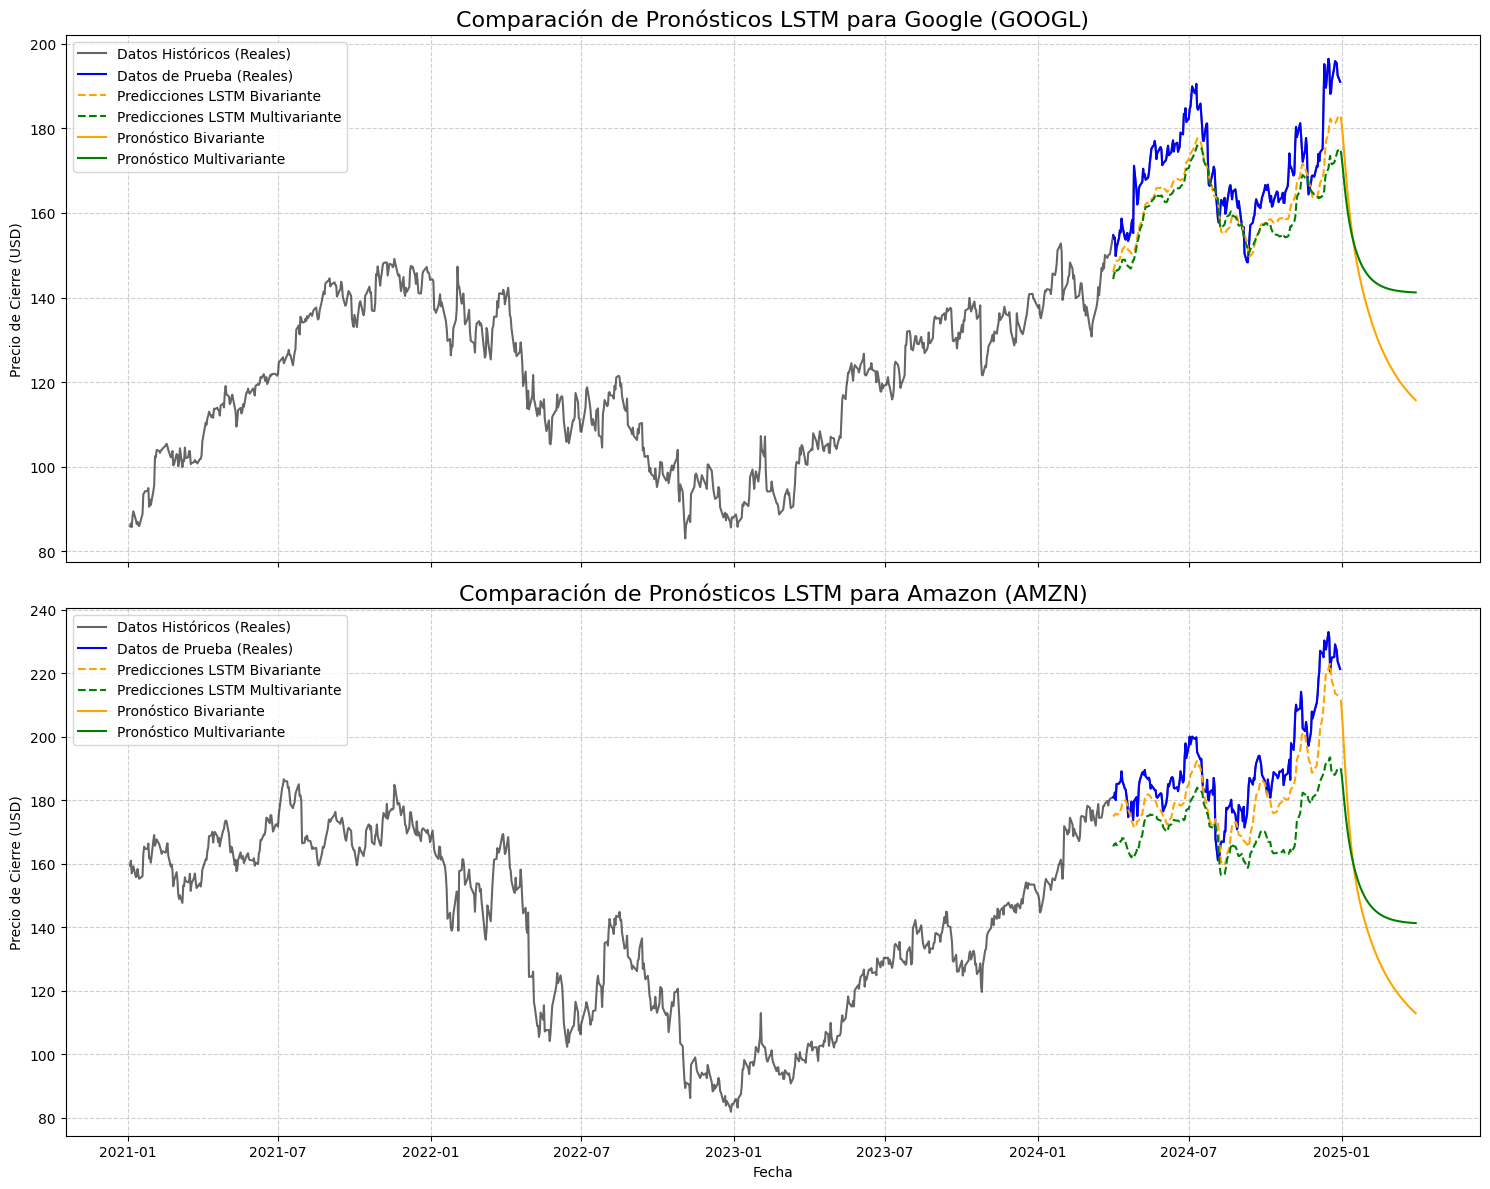

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# --- Gráfico para Google ---
ax1.plot(df.index, df['GOOGL_Close'], label='Datos Históricos (Reales)', color='black', alpha=0.6)
ax1.plot(df_bivariate.index[train_size_bivariate+n_steps:], y_test_biv_real[:, 0], label='Datos de Prueba (Reales)', color='blue')
ax1.plot(df_bivariate.index[train_size_bivariate+n_steps:], predictions_biv[:, 0], label='Predicciones LSTM Bivariante', color='orange', linestyle='--')
ax1.plot(df_multivariate.index[train_size_multivariate+n_steps:], predictions_multi[:, 0], label='Predicciones LSTM Multivariante', color='green', linestyle='--')
ax1.plot(forecast_dates_biv, future_predictions_biv[:, 0], label='Pronóstico Bivariante', color='orange')
ax1.plot(forecast_dates_multi, future_predictions_multi[:, 0], label='Pronóstico Multivariante', color='green')
ax1.set_title('Comparación de Pronósticos LSTM para Google (GOOGL)', fontsize=16)
ax1.set_ylabel('Precio de Cierre (USD)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Gráfico para Amazon ---
ax2.plot(df.index, df['AMZN_Close'], label='Datos Históricos (Reales)', color='black', alpha=0.6)
ax2.plot(df_bivariate.index[train_size_bivariate+n_steps:], y_test_biv_real[:, 1], label='Datos de Prueba (Reales)', color='blue')
ax2.plot(df_bivariate.index[train_size_bivariate+n_steps:], predictions_biv[:, 1], label='Predicciones LSTM Bivariante', color='orange', linestyle='--')
ax2.plot(df_multivariate.index[train_size_multivariate+n_steps:], predictions_multi[:, 1], label='Predicciones LSTM Multivariante', color='green', linestyle='--')
ax2.plot(forecast_dates_biv, future_predictions_biv[:, 1], label='Pronóstico Bivariante', color='orange')
ax2.plot(forecast_dates_multi, future_predictions_multi[:, 1], label='Pronóstico Multivariante', color='green')
ax2.set_title('Comparación de Pronósticos LSTM para Amazon (AMZN)', fontsize=16)
ax2.set_ylabel('Precio de Cierre (USD)')
ax2.set_xlabel('Fecha')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [21]:
# Contar el número total de características en el dataset
n_features = df_multivariate.shape[1]

# Definir la arquitectura del modelo
model_multivariate_full = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train_multi.shape[1], n_features)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=n_features) # <-- La capa de salida ahora predice TODAS las características
])

# Compilar el modelo
model_multivariate_full.compile(optimizer='adam', loss='mean_squared_error')

# Para el entrenamiento, usamos el conjunto de datos completo como 'y'
# El modelo aprenderá a predecir el siguiente estado de todas las variables
y_train_multi_full = X_train_multi[:, -1, :] # Usamos el último paso del input como target

# Reajustamos y_train para que tenga la forma correcta para el modelo completo
# Necesitamos crear las secuencias para 'y' también
_, y_train_multi_full = create_sequences(scaled_data_multivariate[:train_size_multivariate+n_steps], n_steps)


# Entrenar el modelo
print("\nEntrenando el modelo LSTM multivariante completo...")
history_multivariate_full = model_multivariate_full.fit(X_train_multi, y_train_multi_full, epochs=50, batch_size=32, validation_split=0.1, verbose=1)
print("Entrenamiento completado.")


Entrenando el modelo LSTM multivariante completo...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0861 - val_loss: 0.0207
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0204 - val_loss: 0.0096
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - loss: 0.0158 - val_loss: 0.0078
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0148 - val_loss: 0.0078
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0139 - val_loss: 0.0074
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0126 - val_loss: 0.0067
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0123 - val_loss: 0.0074
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0119 - val_loss: 0.0073
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - loss: 0.0116 - val_loss: 0.0068
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0104 - val_loss: 0.0063
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0105 - val_loss: 0.0062
Epoch 1

In [22]:
# Tomar la última secuencia de datos reales
last_sequence_full = scaled_data_multivariate[-n_steps:]
future_predictions_full = []

current_batch = last_sequence_full.reshape(1, n_steps, n_features)

for i in range(n_future_days):
    # Predecir el siguiente estado completo de todas las variables
    future_pred = model_multivariate_full.predict(current_batch)[0]
    future_predictions_full.append(future_pred)

    # Actualizar el batch para la siguiente predicción con la nueva predicción completa
    current_batch = np.append(current_batch[:, 1:, :], [[future_pred]], axis=1)

# Invertir la escala de las predicciones futuras
future_predictions_full = scaler_multivariate.inverse_transform(future_predictions_full)

# Crear un índice de fechas para el pronóstico
forecast_dates_full = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=n_future_days)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━

In [23]:
# Crear un DataFrame con los pronósticos futuros de todas las variables
forecast_df_full = pd.DataFrame(future_predictions_full, index=forecast_dates_full, columns=df.columns)

# Cambiar el nombre del índice para mayor claridad
forecast_df_full.index.name = 'Fecha_Pronostico'

# Mostrar una muestra de la tabla de pronósticos
print("--- Muestra de Pronósticos a Futuro (Modelo Multivariante Completo) ---")
print("\nInicio del período de pronóstico:")
print(forecast_df_full.head())
print("\nFinal del período de pronóstico:")
print(forecast_df_full.tail())

# (Opcional) Guardar la tabla completa en un CSV
forecast_df_full.to_csv('forecast_multivariate_full_marzo2025.csv')

--- Muestra de Pronósticos a Futuro (Modelo Multivariante Completo) ---

Inicio del período de pronóstico:
                  GOOGL_Close  AMZN_Close  Treasury_10Y        VIX  \
Fecha_Pronostico                                                     
2024-12-31         175.269779  173.417722      4.385301  14.864766   
2025-01-01         174.164986  171.483554      4.364975  14.963867   
2025-01-02         172.441454  169.057611      4.343604  15.090188   
2025-01-03         170.369364  166.451981      4.322174  15.172307   
2025-01-04         168.122156  163.834174      4.301483  15.196176   

                        SP500        NASDAQ  GOOGL_Return_1d  AMZN_Return_1d  \
Fecha_Pronostico                                                               
2024-12-31        5096.262920  17047.417273        -0.004380       -0.007233   
2025-01-01        5076.122955  16985.641802        -0.005698       -0.008787   
2025-01-02        5046.534904  16862.018430        -0.006492       -0.009880   
20

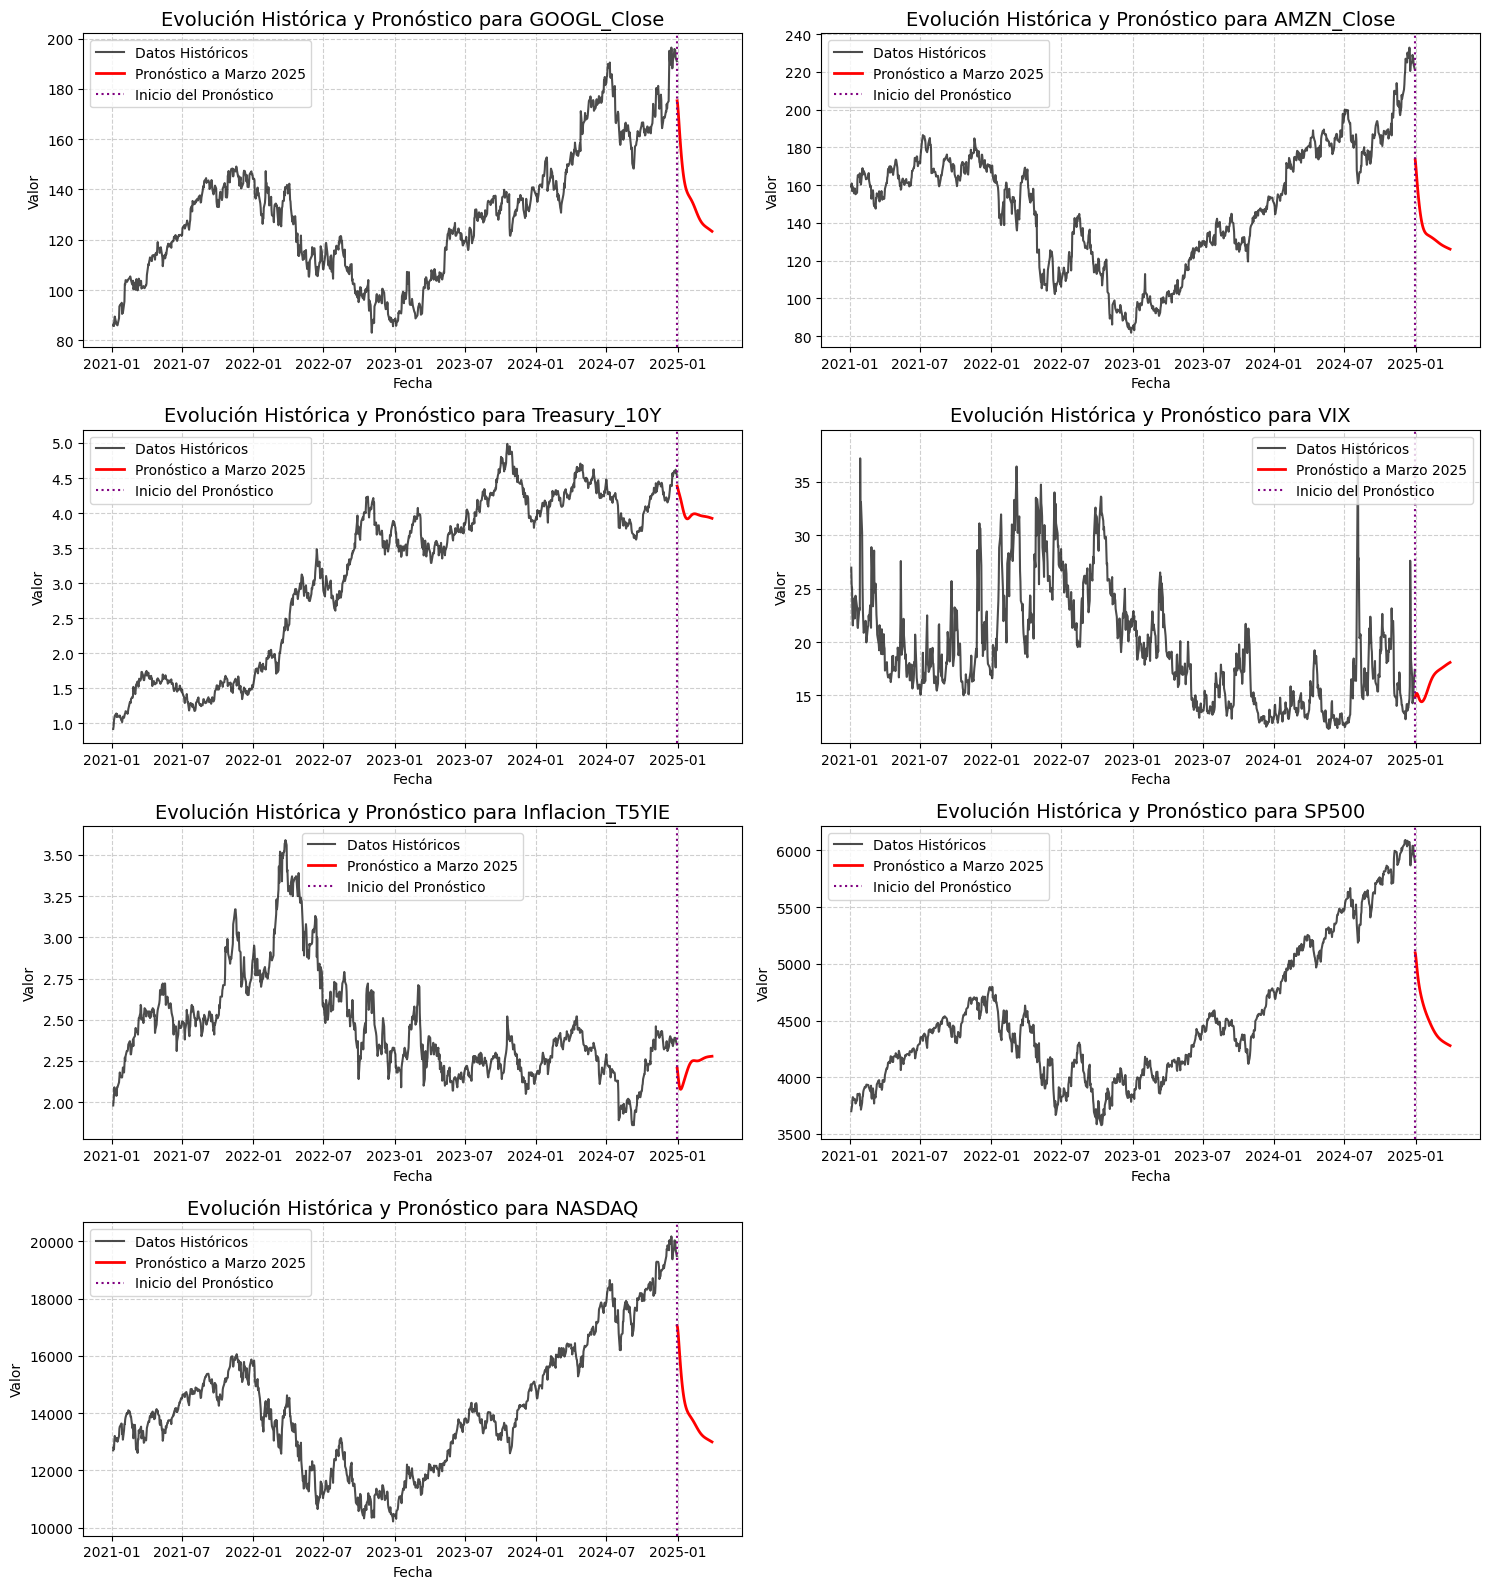

In [24]:
import matplotlib.pyplot as plt

# Seleccionar las columnas que queremos graficar
# Puedes añadir o quitar variables de esta lista según tu interés
columns_to_plot = [
    'GOOGL_Close',
    'AMZN_Close',
    'Treasury_10Y',
    'VIX',
    'Inflacion_T5YIE',
    'SP500',
    'NASDAQ'
]

# Determinar el número de filas y columnas para la cuadrícula de gráficos
n_cols = 2
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols # Calcula las filas necesarias

# Crear la figura y los ejes para los subgráficos
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # Aplanar el array de ejes para iterar fácilmente

# Iterar sobre cada columna para crear su gráfico
for i, col in enumerate(columns_to_plot):
    ax = axes[i]

    # Graficar los datos históricos
    ax.plot(df.index, df[col], label='Datos Históricos', color='black', alpha=0.7)

    # Graficar el pronóstico futuro
    ax.plot(forecast_dates_full, forecast_df_full[col], label='Pronóstico a Marzo 2025', color='red', linewidth=2)

    # Añadir una línea vertical para marcar el inicio del pronóstico
    ax.axvline(df.index[-1], color='purple', linestyle=':', label='Inicio del Pronóstico')

    # Títulos y etiquetas
    ax.set_title(f'Evolución Histórica y Pronóstico para {col}', fontsize=14)
    ax.set_ylabel('Valor')
    ax.set_xlabel('Fecha')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

# Ocultar los ejes no utilizados si el número de gráficos es impar
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()